# Relative O₂ and Plant Areal Fresh Weight

Two bar charts with raw-point overlays and Welch's t-tests. Data are read from `data/o2_relative.csv` and `data/kale_amaranth_afw.csv`.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import ttest_ind_from_stats

fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
SAVE_FOLD = './plots_o2/'
os.makedirs(SAVE_FOLD, exist_ok=True)


def sig_label(p):
    if p < 0.0001: return '****'
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'ns'

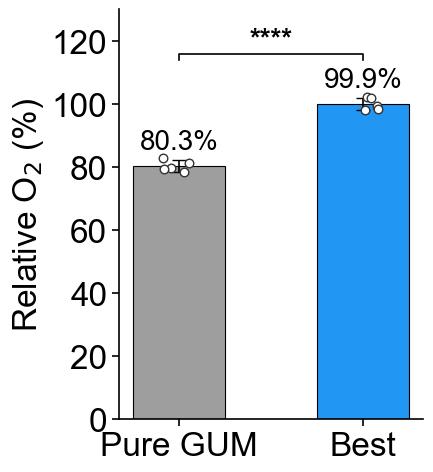

Welch's t-test (n=5/group): t=-16.288, p=2.283e-07 (****)


In [2]:
# Relative O2 (n=5/group) — points from CSV, bars = mean +/- sample SD
o2 = pd.read_csv('data/o2_relative.csv')
order = ['Pure GUM', 'Best']
raw_points = [o2.loc[o2.group == g, 'relative_o2_pct'].values for g in order]
values = [p.mean() for p in raw_points]
errors = [p.std(ddof=1) for p in raw_points]
n = len(raw_points[0])
colors = ['#9E9E9E', '#2196F3']

FIGSIZE = (4, 5)
MARGINS = dict(left=0.20, right=0.96, top=0.94, bottom=0.12)
POINT_KW = dict(s=38, facecolors='white', edgecolors='#333333', linewidths=1.0, zorder=5, clip_on=False)
JITTER = 0.09

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(order, values, width=0.5, color=colors, edgecolor='black', linewidth=0.8,
              yerr=errors, capsize=5, error_kw={'linewidth': 1.2})

jitter_rng = np.random.default_rng(0)
for bar, pts in zip(bars, raw_points):
    xc = bar.get_x() + bar.get_width() / 2
    jit = jitter_rng.uniform(-JITTER, JITTER, len(pts))
    ax.scatter(xc + jit, pts, **POINT_KW)

for bar, val, err in zip(bars, values, errors):
    ax.text(bar.get_x() + bar.get_width() / 2, val + err + 1.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=20)

res = ttest_ind_from_stats(values[0], errors[0], n, values[1], errors[1], n, equal_var=False)
star = sig_label(res.pvalue)
y_bracket = max(v + e for v, e in zip(values, errors)) + 12
h = 2.0
ax.plot([0, 0, 1, 1], [y_bracket, y_bracket + h, y_bracket + h, y_bracket], lw=1.2, color='black')
ax.text(0.5, y_bracket + h + 0.5, star, ha='center', va='bottom',
        fontsize=20 if star != 'ns' else 14, fontweight='bold' if star != 'ns' else 'normal')

ax.set_ylim(0, 130)
ax.set_yticks([0, 20, 40, 60, 80, 100, 120])
ax.set_ylabel('Relative O$_2$ (%)', fontsize=24)
ax.tick_params(axis='both', labelsize=24, width=1.2, length=5)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
fig.subplots_adjust(**MARGINS)
fig.savefig(SAVE_FOLD + 'o2_relative.svg', format='svg', bbox_inches='tight')
plt.show()
print(f"Welch's t-test (n={n}/group): t={res.statistic:.3f}, p={res.pvalue:.4g} ({star})")

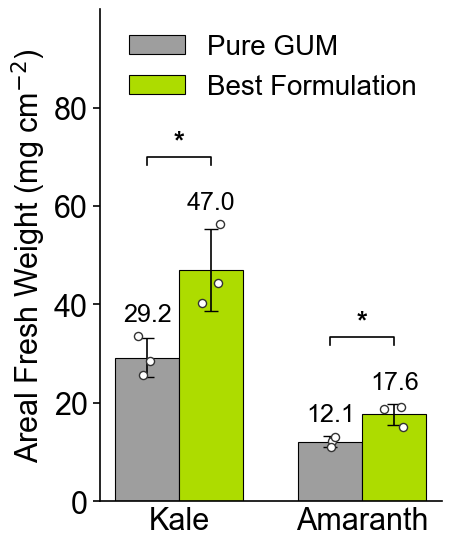

Kale     : t=-3.325, p=0.04798 (*)
Amaranth : t=-3.920, p=0.03194 (*)


In [3]:
# Kale vs Amaranth areal fresh weight (n=3/bar) — raw points from CSV
ka = pd.read_csv('data/kale_amaranth_afw.csv')
def pts(plant, group):
    return ka[(ka.plant == plant) & (ka.group == group)]['areal_fresh_weight_mg_cm2'].values
pts_kale_best, pts_kale_gum = pts('Kale', 'Best'), pts('Kale', 'Pure GUM')
pts_amar_best, pts_amar_gum = pts('Amaranth', 'Best'), pts('Amaranth', 'Pure GUM')

kale_best, kale_best_err = pts_kale_best.mean(), pts_kale_best.std(ddof=1)
kale_gum, kale_gum_err = pts_kale_gum.mean(), pts_kale_gum.std(ddof=1)
amar_best, amar_best_err = pts_amar_best.mean(), pts_amar_best.std(ddof=1)
amar_gum, amar_gum_err = pts_amar_gum.mean(), pts_amar_gum.std(ddof=1)

n = 3
res_kale = ttest_ind_from_stats(kale_gum, kale_gum_err, n, kale_best, kale_best_err, n, equal_var=False)
res_amar = ttest_ind_from_stats(amar_gum, amar_gum_err, n, amar_best, amar_best_err, n, equal_var=False)
star_kale, star_amar = sig_label(res_kale.pvalue), sig_label(res_amar.pvalue)

FIGSIZE = (4.5, 6)
MARGINS = dict(left=0.20, right=0.96, top=0.94, bottom=0.12)
POINT_KW = dict(s=34, facecolors='white', edgecolors='#333333', linewidths=1.0, zorder=5, clip_on=False)
JITTER = 0.055
ANN_PAD, BRACKET_PAD = 2.0, 12.0
bar_width = 0.35
x = np.array([0, 1])

fig, ax = plt.subplots(figsize=FIGSIZE)
bars_gum = ax.bar(x - bar_width / 2, [kale_gum, amar_gum], width=bar_width,
                  color='#9E9E9E', edgecolor='black', linewidth=0.8,
                  yerr=[kale_gum_err, amar_gum_err], capsize=5, error_kw={'linewidth': 1.2}, label='Pure GUM')
best_vals, best_errs, best_pts = [kale_best, amar_best], [kale_best_err, amar_best_err], [pts_kale_best, pts_amar_best]
for i, (val, err) in enumerate(zip(best_vals, best_errs)):
    ax.bar(x[i] + bar_width / 2, val, width=bar_width, color='#ADDC00',
           edgecolor='black', linewidth=0.8, yerr=err, capsize=5, error_kw={'linewidth': 1.2},
           label='Best Formulation' if i == 0 else None)
    ax.text(x[i] + bar_width / 2, max(val + err, best_pts[i].max()) + ANN_PAD, f'{val:.1f}',
            ha='center', va='bottom', fontsize=18)
gum_pts = [pts_kale_gum, pts_amar_gum]
for i, bar in enumerate(bars_gum):
    val, err = [kale_gum, amar_gum][i], [kale_gum_err, amar_gum_err][i]
    ax.text(bar.get_x() + bar.get_width() / 2, max(val + err, gum_pts[i].max()) + ANN_PAD,
            f'{val:.1f}', ha='center', va='bottom', fontsize=18)

jitter_rng = np.random.default_rng(0)
def overlay(xc, pts_):
    jit = jitter_rng.uniform(-JITTER, JITTER, len(pts_))
    ax.scatter(xc + jit, pts_, **POINT_KW)
overlay(x[0] - bar_width / 2, pts_kale_gum); overlay(x[0] + bar_width / 2, pts_kale_best)
overlay(x[1] - bar_width / 2, pts_amar_gum); overlay(x[1] + bar_width / 2, pts_amar_best)

def add_bracket(x_left, x_right, y, h, label):
    ax.plot([x_left, x_left, x_right, x_right], [y, y + h, y + h, y], lw=1.2, color='black')
    ax.text((x_left + x_right) / 2, y + h + 0.3, label, ha='center', va='bottom',
            fontsize=20 if label != 'ns' else 13, fontweight='bold' if label != 'ns' else 'normal')
y_kale = max(kale_gum + kale_gum_err, kale_best + kale_best_err, pts_kale_best.max(), pts_kale_gum.max()) + BRACKET_PAD
add_bracket(x[0] - bar_width / 2, x[0] + bar_width / 2, y_kale, 1.5, star_kale)
y_amar = max(amar_gum + amar_gum_err, amar_best + amar_best_err, pts_amar_best.max(), pts_amar_gum.max()) + BRACKET_PAD
add_bracket(x[1] - bar_width / 2, x[1] + bar_width / 2, y_amar, 1.5, star_amar)

ax.set_xticks(x); ax.set_xticklabels(['Kale', 'Amaranth'])
ax.set_ylabel(r'Areal Fresh Weight (mg cm$^{-2}$)', fontsize=22)
ax.set_ylim(0, 100); ax.set_yticks([0, 20, 40, 60, 80])
ax.tick_params(axis='both', labelsize=22, width=1.2, length=5)
ax.tick_params(axis='x', length=0)
ax.legend(fontsize=20, loc='upper right', frameon=False)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
fig.subplots_adjust(**MARGINS)
fig.savefig(SAVE_FOLD + 'kale_amaranth_afw.svg', format='svg')
plt.show()
print(f"Kale     : t={res_kale.statistic:.3f}, p={res_kale.pvalue:.4g} ({star_kale})")
print(f"Amaranth : t={res_amar.statistic:.3f}, p={res_amar.pvalue:.4g} ({star_amar})")